<a href="https://colab.research.google.com/github/jrangelg/Artificial-intelligence/blob/main/ModelosDupervi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis Discriminante bajo Supuesto de Normalidad

## 1. Introducción

El **Análisis Discriminante Lineal (LDA)** es un método estadístico para clasificar observaciones en grupos previamente definidos a partir de variables explicativas.

Fue introducido por Ronald A. Fisher en 1936 y se basa en el supuesto de **normalidad multivariada** de las poblaciones.

El objetivo es encontrar una función que permita asignar una observación $x$ al grupo más probable.

---

# 2. Supuesto de Normalidad Multivariada

Supongamos que existen $K$ poblaciones.

Si una observación pertenece al grupo $k$, se supone que

$$
X \mid Y=k \sim N_p(\mu_k, \Sigma)
$$

donde

- $X \in \mathbb{R}^p$
- $\mu_k$ es el vector de medias del grupo $k$
- $\Sigma$ es la matriz de covarianza común

La densidad normal multivariada es

$$
f_k(x)=
\frac{1}{(2\pi)^{p/2}|\Sigma|^{1/2}}
\exp
\left(
-\frac{1}{2}
(x-\mu_k)^T
\Sigma^{-1}
(x-\mu_k)
\right)
$$

---

# 3. Regla Bayesiana de Clasificación

Sea $\pi_k$ la probabilidad a priori del grupo $k$.

La probabilidad posterior es

$$
P(Y=k|x)=
\frac{\pi_k f_k(x)}
{\sum_{j=1}^{K}\pi_j f_j(x)}
$$

La regla de clasificación es

$$
\hat{k}=\arg\max_k \pi_k f_k(x)
$$

---

# 4. Derivación de la Función Discriminante

Tomamos logaritmos

$$
\log(\pi_k f_k(x))
$$

Sustituyendo la densidad normal

$$
\log(\pi_k)
-
\frac{1}{2}
(x-\mu_k)^T
\Sigma^{-1}
(x-\mu_k)
-
\frac{1}{2}\log|\Sigma|
$$

Expandiendo el término cuadrático

$$
(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)
=
x^T\Sigma^{-1}x
-2\mu_k^T\Sigma^{-1}x
+\mu_k^T\Sigma^{-1}\mu_k
$$

El término $x^T\Sigma^{-1}x$ es común a todas las clases y se elimina.

Entonces obtenemos la función discriminante

$$
\delta_k(x)=
x^T\Sigma^{-1}\mu_k
-
\frac{1}{2}
\mu_k^T\Sigma^{-1}\mu_k
+
\log(\pi_k)
$$

La regla de decisión es

$$
\hat{k}=\arg\max_k \delta_k(x)
$$

---

# 5. Caso de Dos Clases

Si existen solo dos grupos, la regla se reduce a

clasificar en el grupo 1 si

$$
\delta_1(x)>\delta_2(x)
$$

Esto equivale a

$$
(\mu_1-\mu_2)^T
\Sigma^{-1}x
>
\frac{1}{2}
(\mu_1^T\Sigma^{-1}\mu_1
-
\mu_2^T\Sigma^{-1}\mu_2)
+
\log
\left(
\frac{\pi_1}{\pi_2}
\right)
$$

Por lo tanto la frontera de decisión es un **hiperplano lineal**.

---

# 6. Estimación de Parámetros

En la práctica los parámetros se estiman a partir de los datos.

### Media por grupo

$$
\hat{\mu}_k=
\frac{1}{n_k}
\sum_{i\in G_k}x_i
$$

### Covarianza agrupada

$$
\hat{\Sigma}=
\frac{1}{n-K}
\sum_{k=1}^{K}
\sum_{i\in G_k}
(x_i-\hat{\mu}_k)
(x_i-\hat{\mu}_k)^T
$$

---

# 7. Relación con la Distancia de Mahalanobis

El discriminante puede escribirse usando la **distancia de Mahalanobis**

$$
D_k^2(x)
=
(x-\mu_k)^T
\Sigma^{-1}
(x-\mu_k)
$$

La clasificación equivale a elegir el grupo con **menor distancia de Mahalanobis**.

Bajo normalidad multivariada

$$
D^2 \sim \chi^2_p
$$

---

# 8. Criterio de Fisher

El análisis discriminante busca un vector $w$ que maximice la separación entre grupos.

El criterio de optimización es

$$
\max_w
\frac
{w^T S_B w}
{w^T S_W w}
$$

donde

### Dispersión entre clases

$$
S_B=
\sum_k
n_k
(\mu_k-\mu)
(\mu_k-\mu)^T
$$

### Dispersión dentro de clases

$$
S_W=
\sum_k
\sum_{i\in G_k}
(x_i-\mu_k)
(x_i-\mu_k)^T
$$

Esto conduce al problema de autovalores

$$
S_W^{-1}S_B w=\lambda w
$$

Los vectores propios asociados a los mayores autovalores definen las **direcciones discriminantes**.



Matriz de confusion LDA
[[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Accuracy LDA
0.9777777777777777
Matriz de confusion QDA
[[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Accuracy QDA
0.9777777777777777


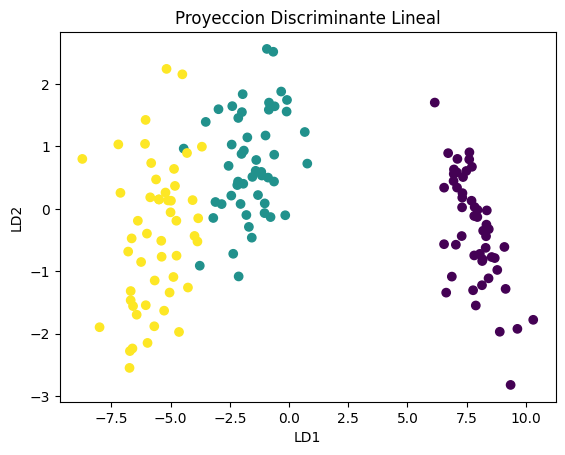

In [16]:
# ======================================
# ANALISIS DISCRIMINANTE LINEAL Y CUADRATICO
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# ==============================
# Cargar datos
# ==============================

data = load_iris()

X = data.data
y = data.target

# ==============================
# Dividir muestra
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# ==============================
# LDA
# ==============================

lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

pred_lda = lda.predict(X_test)

print("Matriz de confusion LDA")
print(confusion_matrix(y_test, pred_lda))

print("Accuracy LDA")
print(accuracy_score(y_test, pred_lda))


# ==============================
# QDA
# ==============================

qda = QuadraticDiscriminantAnalysis()

qda.fit(X_train, y_train)

pred_qda = qda.predict(X_test)

print("Matriz de confusion QDA")
print(confusion_matrix(y_test, pred_qda))

print("Accuracy QDA")
print(accuracy_score(y_test, pred_qda))


# ==============================
# Proyeccion LDA
# ==============================

X_lda = lda.transform(X)

plt.scatter(X_lda[:,0], X_lda[:,1], c=y)

plt.xlabel("LD1")
plt.ylabel("LD2")

plt.title("Proyeccion Discriminante Lineal")

plt.show()

# Análisis Discriminante Lineal y Cuadrático

## 1. Introducción

El **análisis discriminante** es un conjunto de técnicas estadísticas utilizadas para clasificar observaciones en grupos previamente definidos a partir de variables explicativas.

Uno de los enfoques más clásicos es el desarrollado por Ronald A. Fisher, conocido como **Análisis Discriminante Lineal (LDA)**.

La idea es encontrar una regla de decisión que permita asignar una observación $x$ al grupo más probable.

---

# 2. Supuesto de Normalidad Multivariada

Supongamos que existen $K$ poblaciones.

Si una observación pertenece al grupo $k$, se asume

$$
X|Y=k \sim N_p(\mu_k,\Sigma_k)
$$

donde

- $X \in \mathbb{R}^p$
- $\mu_k$ es el vector de medias
- $\Sigma_k$ es la matriz de covarianza

La densidad normal multivariada es

$$
f_k(x)=
\frac{1}{(2\pi)^{p/2}|\Sigma_k|^{1/2}}
\exp
\left(
-\frac{1}{2}(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)
\right)
$$

---

# 3. Regla Bayesiana de Clasificación

Sea $\pi_k$ la probabilidad a priori de la clase $k$.

La probabilidad posterior es

$$
P(Y=k|x)=
\frac{\pi_k f_k(x)}
{\sum_{j=1}^K \pi_j f_j(x)}
$$

La regla de clasificación consiste en asignar $x$ al grupo que maximice

$$
\pi_k f_k(x)
$$

o equivalentemente

$$
\hat{k}=\arg\max_k \log(\pi_k f_k(x))
$$

---

# 4. Análisis Discriminante Lineal (LDA)

El **discriminante lineal** supone que todas las clases comparten la misma matriz de covarianza

$$
\Sigma_1=\Sigma_2=\dots=\Sigma_K=\Sigma
$$

Bajo este supuesto

$$
X|Y=k \sim N(\mu_k,\Sigma)
$$

La función discriminante se obtiene tomando logaritmos

$$
\delta_k(x)=
x^T\Sigma^{-1}\mu_k
-\frac12 \mu_k^T\Sigma^{-1}\mu_k
+\log(\pi_k)
$$

La regla de clasificación es

$$
\hat{k}=\arg\max_k \delta_k(x)
$$

### Propiedad

La frontera de decisión es un **hiperplano lineal**.

---

# 5. Análisis Discriminante Cuadrático (QDA)

El **discriminante cuadrático** permite matrices de covarianza diferentes.

$$
X|Y=k \sim N(\mu_k,\Sigma_k)
$$

La función discriminante es

$$
\delta_k(x)=
-\frac12 \log|\Sigma_k|
-\frac12 (x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)
+\log(\pi_k)
$$

### Propiedad

Las fronteras de decisión son **superficies cuadráticas**.

---

# 6. Estimación de Parámetros

En la práctica los parámetros se estiman con la muestra.

### Media de cada grupo

$$
\hat{\mu}_k=
\frac{1}{n_k}
\sum_{i\in G_k} x_i
$$

### Covarianza agrupada (LDA)

$$
\hat{\Sigma}=
\frac{1}{n-K}
\sum_{k=1}^{K}
\sum_{i\in G_k}
(x_i-\hat{\mu}_k)
(x_i-\hat{\mu}_k)^T
$$

### Covarianza por clase (QDA)

$$
\hat{\Sigma}_k=
\frac{1}{n_k-1}
\sum_{i\in G_k}
(x_i-\hat{\mu}_k)
(x_i-\hat{\mu}_k)^T
$$

---

# 7. Distancia de Mahalanobis

La clasificación también puede expresarse mediante la **distancia de Mahalanobis**

$$
D_k^2(x)=(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)
$$

Bajo normalidad multivariada

$$
D^2 \sim \chi^2_p
$$

---

# 8. Interpretación Geométrica

El análisis discriminante busca una transformación lineal

$$
z=w^Tx
$$

tal que maximice la separación entre clases.

El criterio de Fisher es

$$
\max_w
\frac{w^T S_B w}{w^T S_W w}
$$

donde

### Matriz de dispersión entre clases

$$
S_B=
\sum_k
n_k(\mu_k-\mu)
(\mu_k-\mu)^T
$$

### Matriz de dispersión dentro de clases

$$
S_W=
\sum_k
\sum_{i\in G_k}
(x_i-\mu_k)(x_i-\mu_k)^T
$$

Esto conduce al problema de autovalores

$$
S_W^{-1}S_B w=\lambda w
$$

Los autovectores asociados a los mayores autovalores determinan las **direcciones discriminantes**.

---

# 9. Código en Python

Ejemplo de implementación en Python usando scikit-learn.





In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

data = load_iris()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.3,random_state=0
)

lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()

lda.fit(X_train,y_train)
qda.fit(X_train,y_train)

pred_lda = lda.predict(X_test)
pred_qda = qda.predict(X_test)

print("Matriz de confusion LDA")
print(confusion_matrix(y_test,pred_lda))

print("Matriz de confusion QDA")
print(confusion_matrix(y_test,pred_qda))

Matriz de confusion LDA
[[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]
Matriz de confusion QDA
[[16  0  0]
 [ 0 17  1]
 [ 0  0 11]]


# Máquinas de Soporte Vectorial (SVM) con PySpark

## 1. Introducción

Las **Máquinas de Soporte Vectorial (Support Vector Machines, SVM)** son métodos de aprendizaje supervisado utilizados para clasificación y regresión.

La idea fundamental es encontrar un hiperplano que separe las clases maximizando el margen entre ellas.

Sea un conjunto de datos

$$
(x_1,y_1),(x_2,y_2),\dots,(x_n,y_n)
$$

donde

$$
x_i \in \mathbb{R}^p, \quad y_i \in \{-1,1\}
$$

---

# 2. Hiperplano Separador

Un hiperplano se define como

$$
w^T x + b = 0
$$

donde

- $w$ es el vector normal
- $b$ es el sesgo

Las observaciones se clasifican según

$$
y = \text{sign}(w^T x + b)
$$

---

# 3. Margen Máximo

SVM busca maximizar el margen entre las clases.

Esto equivale a resolver el problema

$$
\min_{w,b} \frac{1}{2}||w||^2
$$

sujeto a

$$
y_i(w^Tx_i+b)\ge 1
$$

---

# 4. Caso No Separables

Se introducen variables de holgura $\xi_i$

$$
\min_{w,b,\xi}
\frac12 ||w||^2 + C \sum \xi_i
$$

sujeto a

$$
y_i(w^Tx_i+b) \ge 1-\xi_i
$$

In [18]:
# ===============================
# INSTALAR PYSPARK
# ===============================

!pip install pyspark

# ===============================
# IMPORTAR LIBRERIAS
# ===============================

from pyspark.sql import SparkSession

from pyspark.ml.classification import LinearSVC
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import BinaryClassificationEvaluator

from pyspark.ml.linalg import Vectors

# ===============================
# CREAR SESION SPARK
# ===============================

spark = SparkSession.builder \
    .appName("SVM PySpark") \
    .getOrCreate()

# ===============================
# DATASET DE EJEMPLO
# ===============================

data = [
(0.0,1.0,0),
(1.0,2.0,0),
(1.3,1.8,0),
(3.0,3.5,1),
(3.2,4.0,1),
(4.0,4.5,1)
]

columns = ["x1","x2","label"]

df = spark.createDataFrame(data,columns)

# ===============================
# VECTOR DE FEATURES
# ===============================

assembler = VectorAssembler(
    inputCols=["x1","x2"],
    outputCol="features"
)

data = assembler.transform(df)

# ===============================
# SPLIT TRAIN TEST
# ===============================

train,test = data.randomSplit([0.7,0.3],seed=42)

# ===============================
# MODELO SVM
# ===============================

svm = LinearSVC(
    featuresCol="features",
    labelCol="label",
    maxIter=10,
    regParam=0.1
)

model = svm.fit(train)

# ===============================
# PREDICCIONES
# ===============================

predictions = model.transform(test)

predictions.select("features","label","prediction").show()

# ===============================
# EVALUACION
# ===============================

evaluator = BinaryClassificationEvaluator()

auc = evaluator.evaluate(predictions)

print("AUC:",auc)

# ===============================
# COEFICIENTES DEL MODELO
# ===============================

print("Vector w:", model.coefficients)
print("Intercepto:", model.intercept)

+---------+-----+----------+
| features|label|prediction|
+---------+-----+----------+
|[1.3,1.8]|    0|       0.0|
|[3.0,3.5]|    1|       1.0|
+---------+-----+----------+

AUC: 1.0
Vector w: [0.448047434855182,0.5091504958757415]
Intercepto: -2.4684957427680487


Vector w: [0.4935943  0.61749706]
Intercepto: -3.4443652886133895


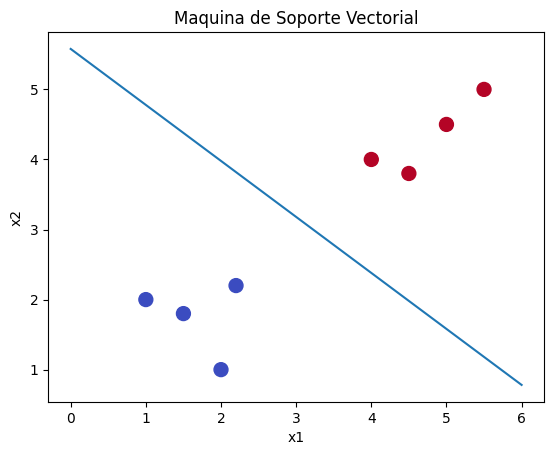

In [12]:
# =====================================
# INSTALAR PYSPARK
# =====================================

!pip install pyspark

# =====================================
# LIBRERIAS
# =====================================

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LinearSVC

import numpy as np
import matplotlib.pyplot as plt

# =====================================
# SESION SPARK
# =====================================

spark = SparkSession.builder.appName("SVM").getOrCreate()

# =====================================
# DATASET
# =====================================

data = [

(1.0,2.0,0),
(1.5,1.8,0),
(2.0,1.0,0),
(2.2,2.2,0),

(4.0,4.0,1),
(4.5,3.8,1),
(5.0,4.5,1),
(5.5,5.0,1)

]

columns = ["x1","x2","label"]

df = spark.createDataFrame(data,columns)

# =====================================
# VECTOR DE FEATURES
# =====================================

assembler = VectorAssembler(
    inputCols=["x1","x2"],
    outputCol="features"
)

data_spark = assembler.transform(df)

# =====================================
# MODELO SVM
# =====================================

svm = LinearSVC(
    featuresCol="features",
    labelCol="label",
    maxIter=20,
    regParam=0.1
)

model = svm.fit(data_spark)

# =====================================
# OBTENER PARAMETROS DEL HIPERPLANO
# =====================================

w = model.coefficients.toArray()
b = model.intercept

print("Vector w:", w)
print("Intercepto:", b)

# =====================================
# CONVERTIR A PANDAS PARA GRAFICA
# =====================================

pdf = df.toPandas()

X = pdf[["x1","x2"]].values
y = pdf["label"].values

# =====================================
# GRAFICA
# =====================================

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm",
    s=100
)

# hiperplano
x_vals = np.linspace(0,6,100)

y_vals = -(w[0]*x_vals + b)/w[1]

plt.plot(x_vals,y_vals)

plt.xlabel("x1")
plt.ylabel("x2")

plt.title("Maquina de Soporte Vectorial")

plt.show()

# Kernels en Máquinas de Soporte Vectorial

## 1. Introducción

Las **Máquinas de Soporte Vectorial (SVM)** son algoritmos de aprendizaje supervisado utilizados para clasificación y regresión.

Cuando los datos **no son linealmente separables**, se utiliza el **truco del kernel** para proyectar los datos a un espacio de mayor dimensión donde sí puedan separarse linealmente.

La idea es transformar

$$
x \in \mathbb{R}^p
$$

a un espacio de características

$$
\phi(x) \in \mathcal{H}
$$

donde $\mathcal{H}$ es un espacio de dimensión mayor.

---

# 2. Problema de Optimización SVM

El problema primal es

$$
\min_{w,b,\xi}
\frac{1}{2}||w||^2 + C\sum_{i=1}^n \xi_i
$$

sujeto a

$$
y_i(w^Tx_i + b) \ge 1 - \xi_i
$$

$$
\xi_i \ge 0
$$

donde

- $w$ vector de pesos
- $b$ intercepto
- $\xi_i$ variables de holgura
- $C$ parámetro de penalización

---

# 3. Problema Dual

Aplicando multiplicadores de Lagrange se obtiene el problema dual

$$
\max_{\alpha}
\sum_{i=1}^n \alpha_i
-
\frac{1}{2}
\sum_{i=1}^n
\sum_{j=1}^n
\alpha_i \alpha_j y_i y_j x_i^T x_j
$$

sujeto a

$$
0 \le \alpha_i \le C
$$

$$
\sum_{i=1}^n \alpha_i y_i = 0
$$

La solución depende solo de **productos internos**

$$
x_i^T x_j
$$

Esto permite introducir **kernels**.

---

# 4. Truco del Kernel

En lugar de calcular

$$
\phi(x_i)^T \phi(x_j)
$$

se define una función kernel

$$
K(x_i,x_j)=\phi(x_i)^T\phi(x_j)
$$

Esto evita calcular explícitamente la transformación $\phi$.

---

# 5. Función de Decisión

La función de clasificación se escribe

$$
f(x)=
\sum_{i=1}^n
\alpha_i y_i K(x_i,x)
+
b
$$

Solo los puntos con $\alpha_i>0$ son relevantes.

Estos se llaman **vectores de soporte**.

---

# 6. Kernels Comunes

## Kernel lineal

$$
K(x,z)=x^Tz
$$

## Kernel polinomial

$$
K(x,z)=(x^Tz+c)^d
$$

## Kernel gaussiano (RBF)

$$
K(x,z)=
\exp
\left(
-\gamma ||x-z||^2
\right)
$$

## Kernel sigmoide

$$
K(x,z)=\tanh(\kappa x^Tz + c)
$$

---

# 7. Condición de Mercer

Para que una función sea un kernel válido debe satisfacer la **condición de Mercer**.

Una función $K(x,z)$ es kernel si la matriz

$$
K_{ij}=K(x_i,x_j)
$$

es **simétrica y definida positiva**.

---

# 8. Interpretación Geométrica

El kernel permite trabajar en un espacio de dimensión mayor.

Ejemplo:

Datos no separables en $\mathbb{R}^2$ pueden separarse en $\mathbb{R}^3$ mediante

$$
\phi(x_1,x_2)=(x_1,x_2,x_1^2+x_2^2)
$$

---

# 9. Ejemplo en Python

---


Los **kernels** permiten aplicar SVM a problemas no lineales mediante transformaciones implícitas del espacio de características.

El **truco del kernel** es una de las ideas fundamentales del aprendizaje automático moderno, ya que permite trabajar en espacios de dimensión muy alta sin calcular explícitamente la transformación.

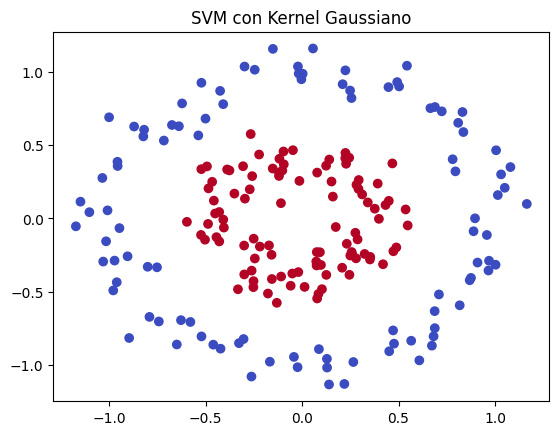

In [13]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.svm import SVC

# generar datos no lineales
X, y = make_circles(
    n_samples=200,
    noise=0.1,
    factor=0.4
)

# modelo SVM con kernel RBF
model = SVC(kernel="rbf")

model.fit(X,y)

# grafica
plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm"
)

plt.title("SVM con Kernel Gaussiano")

plt.show()

MEDIA POR CLASE
             x1        x2
clase                    
0     -0.043604  0.650021
1      1.092169 -0.105629

COVARIANZA POR CLASE
                x1        x2
clase                       
0     x1  0.618434  0.005340
      x2  0.005340  0.142876
1     x1  0.559720  0.043228
      x2  0.043228  0.174452

COVARIANZA GLOBAL
[[ 0.91125623 -0.19153808]
 [-0.19153808  0.30061   ]]

TABLA COMPARATIVA
  Modelo  Accuracy
0    LDA     0.750
1    QDA     0.750
2    SVM     0.875

CONFUSION LDA
[[41 14]
 [16 49]]

CONFUSION QDA
[[41 14]
 [16 49]]

CONFUSION SVM
[[48  7]
 [ 8 57]]


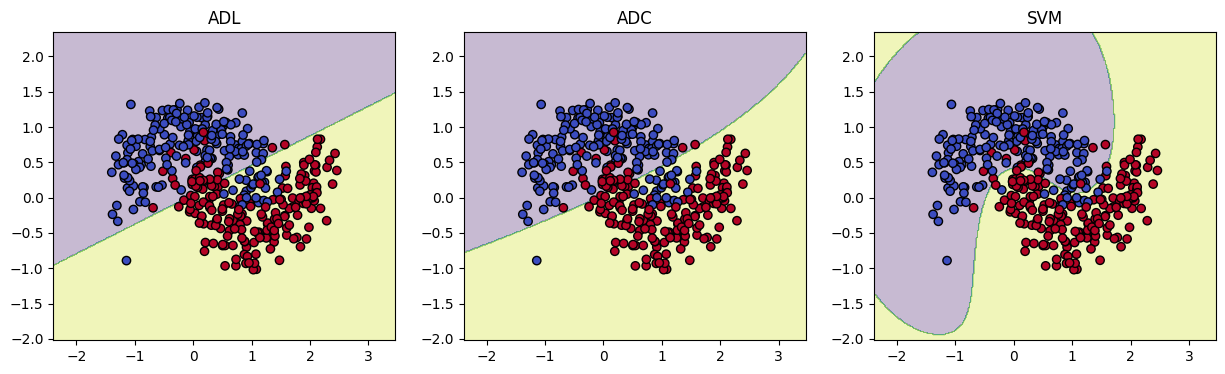

In [14]:
# ============================================
# COMPARACION: LDA vs QDA vs SVM
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.svm import SVC

# ============================================
# GENERAR DATOS NO LINEALES
# ============================================

X, y = make_moons(
    n_samples=400,
    noise=0.25,
    random_state=42
)

# ============================================
# DIVIDIR DATOS
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# ============================================
# MATRICES ESTADISTICAS
# ============================================

df = pd.DataFrame(X_train, columns=["x1","x2"])
df["clase"] = y_train

print("MEDIA POR CLASE")
print(df.groupby("clase").mean())

print("\nCOVARIANZA POR CLASE")
print(df.groupby("clase").cov())

print("\nCOVARIANZA GLOBAL")
print(np.cov(X_train.T))

# ============================================
# MODELOS
# ============================================

lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()
svm = SVC(kernel="rbf")

lda.fit(X_train,y_train)
qda.fit(X_train,y_train)
svm.fit(X_train,y_train)

# ============================================
# PREDICCIONES
# ============================================

pred_lda = lda.predict(X_test)
pred_qda = qda.predict(X_test)
pred_svm = svm.predict(X_test)

# ============================================
# TABLA DE RESULTADOS
# ============================================

results = pd.DataFrame({

"Modelo":["LDA","QDA","SVM"],

"Accuracy":[
accuracy_score(y_test,pred_lda),
accuracy_score(y_test,pred_qda),
accuracy_score(y_test,pred_svm)
]

})

print("\nTABLA COMPARATIVA")
print(results)

print("\nCONFUSION LDA")
print(confusion_matrix(y_test,pred_lda))

print("\nCONFUSION QDA")
print(confusion_matrix(y_test,pred_qda))

print("\nCONFUSION SVM")
print(confusion_matrix(y_test,pred_svm))

# ============================================
# FUNCION PARA GRAFICAR FRONTERAS
# ============================================

def plot_model(model,title):

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,300),
        np.linspace(y_min,y_max,300)
    )

    Z = model.predict(
        np.c_[xx.ravel(),yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    plt.contourf(xx,yy,Z,alpha=0.3)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        cmap="coolwarm",
        edgecolor="k"
    )

    plt.title(title)

# ============================================
# GRAFICAS
# ============================================

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plot_model(lda,"ADL")

plt.subplot(1,3,2)
plot_model(qda,"ADC")

plt.subplot(1,3,3)
plot_model(svm,"SVM")

plt.show()

# Modelos de Clasificación: Logístico, ADL, ADC y Máquinas de Soporte Vectorial

## 1. Introducción

En aprendizaje supervisado, el problema de **clasificación** consiste en asignar una observación

$$
x \in \mathbb{R}^p
$$

a una de $K$ clases posibles.

Entre los métodos estadísticos y de aprendizaje automático más importantes se encuentran:

- Regresión logística
- Análisis discriminante lineal (ADL)
- Análisis discriminante cuadrático (ADC)
- Máquinas de soporte vectorial (SVM)

Cada método se basa en distintos principios: probabilísticos, geométricos y de optimización.

---

# 2. Modelo Logístico

Sea $Y \in \{0,1\}$ una variable binaria.

El modelo logístico supone

$$
P(Y=1|X=x)=\pi(x)
$$

donde

$$
\pi(x)=\frac{\exp(\beta_0+\beta^Tx)}{1+\exp(\beta_0+\beta^Tx)}
$$

Equivalentemente

$$
\log\left(\frac{\pi(x)}{1-\pi(x)}\right)=\beta_0+\beta^Tx
$$

La función

$$
\log\left(\frac{\pi(x)}{1-\pi(x)}\right)
$$

se denomina **logit**.

---

## Estimación por Máxima Verosimilitud

La función de verosimilitud es

$$
L(\beta)=\prod_{i=1}^n \pi(x_i)^{y_i}(1-\pi(x_i))^{1-y_i}
$$

El logaritmo de la verosimilitud es

$$
\ell(\beta)=\sum_{i=1}^n
\left[
y_i\log(\pi(x_i))+(1-y_i)\log(1-\pi(x_i))
\right]
$$

Los parámetros se estiman resolviendo

$$
\frac{\partial \ell(\beta)}{\partial \beta}=0
$$

usando algoritmos iterativos.

---

# 3. Análisis Discriminante Lineal (ADL)

Supongamos $K$ clases.

Se asume

$$
X|Y=k \sim N_p(\mu_k,\Sigma)
$$

donde

- $\mu_k$ es el vector de medias
- $\Sigma$ es la matriz de covarianza común.

La densidad normal multivariada es

$$
f_k(x)=
\frac{1}{(2\pi)^{p/2}|\Sigma|^{1/2}}
\exp
\left(
-\frac12 (x-\mu_k)^T\Sigma^{-1}(x-\mu_k)
\right)
$$

---

## Regla de Clasificación

La regla de Bayes asigna $x$ a la clase que maximiza

$$
\pi_k f_k(x)
$$

Tomando logaritmos se obtiene la función discriminante

$$
\delta_k(x)=
x^T\Sigma^{-1}\mu_k
-
\frac12\mu_k^T\Sigma^{-1}\mu_k
+
\log(\pi_k)
$$

La clasificación es

$$
\hat{k}=\arg\max_k \delta_k(x)
$$

La frontera de decisión es **lineal**.

---

# 4. Análisis Discriminante Cuadrático (ADC)

En el discriminante cuadrático cada clase tiene su propia matriz de covarianza

$$
X|Y=k \sim N_p(\mu_k,\Sigma_k)
$$

La función discriminante es

$$
\delta_k(x)=
-\frac12\log|\Sigma_k|
-
\frac12(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)
+
\log(\pi_k)
$$

Las fronteras de decisión son **cuadráticas**.

---

# 5. Distancia de Mahalanobis

En el caso del discriminante lineal la clasificación puede escribirse en términos de la distancia

$$
D_k^2(x)=(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)
$$

Bajo normalidad multivariada

$$
D^2 \sim \chi^2_p
$$

---

# 6. Máquinas de Soporte Vectorial

Las **SVM** buscan encontrar el hiperplano que separa las clases con el mayor margen posible.

Sea un conjunto de datos

$$
(x_i,y_i),\quad y_i \in \{-1,1\}
$$

El hiperplano es

$$
w^Tx+b=0
$$

---

## Problema de Optimización

$$
\min_{w,b} \frac12 ||w||^2
$$

sujeto a

$$
y_i(w^Tx_i+b)\ge1
$$

---

## Caso No Separables

Se introducen variables de holgura

$$
\min_{w,b,\xi}
\frac12||w||^2+C\sum_{i=1}^n\xi_i
$$

sujeto a

$$
y_i(w^Tx_i+b)\ge1-\xi_i
$$

---

# 7. Formulación Dual

El problema dual es

$$
\max_{\alpha}
\sum_{i=1}^n\alpha_i
-
\frac12
\sum_{i=1}^n\sum_{j=1}^n
\alpha_i\alpha_jy_iy_jx_i^Tx_j
$$

sujeto a

$$
0\le\alpha_i\le C
$$

$$
\sum_{i=1}^n\alpha_i y_i=0
$$

---

# 8. Truco del Kernel

Para problemas no lineales se utiliza una función kernel

$$
K(x_i,x_j)=\phi(x_i)^T\phi(x_j)
$$

Ejemplos:

Kernel lineal

$$
K(x,z)=x^Tz
$$

Kernel polinomial

$$
K(x,z)=(x^Tz+c)^d
$$

Kernel gaussiano

$$
K(x,z)=\exp(-\gamma||x-z||^2)
$$

---

# 9. Comparación de Métodos

| Método | Supuesto | Frontera |
|------|------|------|
| Logístico | Modelo probabilístico | Lineal |
| ADL | Normal multivariada con covarianza común | Lineal |
| ADC | Normal multivariada con covarianza distinta | Cuadrática |
| SVM | Maximización del margen | Lineal o no lineal |

---


Los métodos de clasificación difieren en sus supuestos teóricos:

- La **regresión logística** es un modelo probabilístico.
- El **ADL y ADC** se basan en modelos generativos con normalidad multivariada.
- Las **SVM** se basan en optimización convexa y maximización del margen.

CONFUSION LOGISTICO
[[60 13]
 [14 63]]

CONFUSION LDA
[[60 13]
 [14 63]]

CONFUSION QDA
[[60 13]
 [14 63]]

CONFUSION SVM
[[69  4]
 [ 2 75]]

TABLA DE METRICAS
      Modelo  Accuracy  Precision    Recall        F1
0  Logistico      0.82   0.828947  0.818182  0.823529
1        LDA      0.82   0.828947  0.818182  0.823529
2        QDA      0.82   0.828947  0.818182  0.823529
3        SVM      0.96   0.949367  0.974026  0.961538


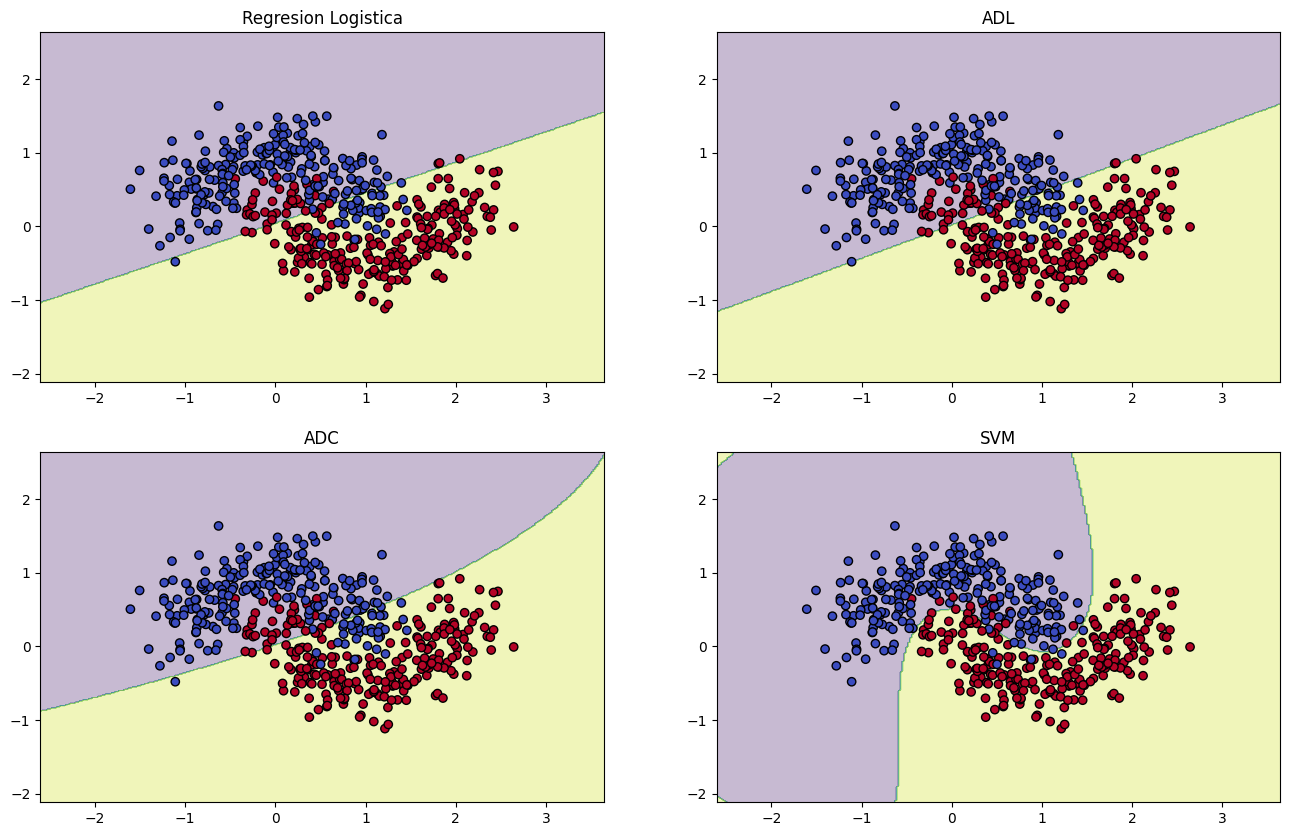

In [15]:
# ============================================
# COMPARACION DE 4 MODELOS DE CLASIFICACION
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.svm import SVC

from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# ============================================
# GENERAR DATOS NO LINEALES
# ============================================

X, y = make_moons(
    n_samples=500,
    noise=0.25,
    random_state=42
)

# ============================================
# DIVISION TRAIN TEST
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

# ============================================
# MODELOS
# ============================================

logit = LogisticRegression()
lda = LinearDiscriminantAnalysis()
qda = QuadraticDiscriminantAnalysis()
svm = SVC(kernel="rbf")

logit.fit(X_train,y_train)
lda.fit(X_train,y_train)
qda.fit(X_train,y_train)
svm.fit(X_train,y_train)

# ============================================
# PREDICCIONES
# ============================================

pred_log = logit.predict(X_test)
pred_lda = lda.predict(X_test)
pred_qda = qda.predict(X_test)
pred_svm = svm.predict(X_test)

# ============================================
# MATRICES DE CONFUSION
# ============================================

print("CONFUSION LOGISTICO")
print(confusion_matrix(y_test,pred_log))

print("\nCONFUSION LDA")
print(confusion_matrix(y_test,pred_lda))

print("\nCONFUSION QDA")
print(confusion_matrix(y_test,pred_qda))

print("\nCONFUSION SVM")
print(confusion_matrix(y_test,pred_svm))

# ============================================
# TABLA DE METRICAS
# ============================================

metricas = pd.DataFrame({

"Modelo":[
"Logistico",
"LDA",
"QDA",
"SVM"
],

"Accuracy":[
accuracy_score(y_test,pred_log),
accuracy_score(y_test,pred_lda),
accuracy_score(y_test,pred_qda),
accuracy_score(y_test,pred_svm)
],

"Precision":[
precision_score(y_test,pred_log),
precision_score(y_test,pred_lda),
precision_score(y_test,pred_qda),
precision_score(y_test,pred_svm)
],

"Recall":[
recall_score(y_test,pred_log),
recall_score(y_test,pred_lda),
recall_score(y_test,pred_qda),
recall_score(y_test,pred_svm)
],

"F1":[
f1_score(y_test,pred_log),
f1_score(y_test,pred_lda),
f1_score(y_test,pred_qda),
f1_score(y_test,pred_svm)
]

})

print("\nTABLA DE METRICAS")
print(metricas)

# ============================================
# FUNCION PARA GRAFICAR FRONTERAS
# ============================================

def plot_model(model,title):

    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min,x_max,300),
        np.linspace(y_min,y_max,300)
    )

    Z = model.predict(
        np.c_[xx.ravel(),yy.ravel()]
    )

    Z = Z.reshape(xx.shape)

    plt.contourf(xx,yy,Z,alpha=0.3)

    plt.scatter(
        X[:,0],
        X[:,1],
        c=y,
        cmap="coolwarm",
        edgecolor="k"
    )

    plt.title(title)

# ============================================
# GRAFICAS
# ============================================

plt.figure(figsize=(16,10))

plt.subplot(2,2,1)
plot_model(logit,"Regresion Logistica")

plt.subplot(2,2,2)
plot_model(lda,"ADL")

plt.subplot(2,2,3)
plot_model(qda,"ADC")

plt.subplot(2,2,4)
plot_model(svm,"SVM")

plt.show()